# Task 1 — Compreender, auditar e preparar os dados
## 1. Carregamento e limpeza básica

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA_PATH = "Charging_Data_educational.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print(df.shape)
df.info()
df.head()

(441077, 47)
<class 'pandas.DataFrame'>
RangeIndex: 441077 entries, 0 to 441076
Data columns (total 47 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   UserID                                        441077 non-null  int64  
 1   Charging Post ID                              441077 non-null  int64  
 2   Location Information                          441077 non-null  str    
 3   District Name                                 441077 non-null  str    
 4   Order creation time                           441077 non-null  str    
 5   Transaction power/kwh                         441077 non-null  float64
 6   Electricity cost/Yuan                         441077 non-null  float64
 7   Service charge/Yuan                           441077 non-null  float64
 8   Transaction Amount/Yuan                       441077 non-null  float64
 9   Actual Payment/Yuan                           

,UserID,Charging Post ID,Location Information,District Name,Order creation time,Transaction power/kwh,Electricity cost/Yuan,Service charge/Yuan,Transaction Amount/Yuan,Actual Payment/Yuan,Start Time,End Time,Payment time,Temperature(℃),Relative Humidity(%),Precipitation(mm),end_cause,electricity_price,tariff_period,post_previous_sessions_1D,post_previous_abnormal_1D,post_previous_abnormal_rate_1D,post_previous_sessions_7D,post_previous_abnormal_7D,post_previous_abnormal_rate_7D,post_previous_sessions_30D,post_previous_abnormal_30D,post_previous_abnormal_rate_30D,post_hours_since_previous_completed_session,post_no_previous_completed_session,post_hours_since_previous_completed_abnormal,post_no_previous_completed_abnormal,is_new_user,user_previous_sessions_30D,user_previous_abnormal_30D,user_previous_abnormal_rate_30D,user_previous_sessions_180D,user_previous_abnormal_180D,user_previous_abnormal_rate_180D,user_previous_sessions_730D,user_previous_abnormal_730D,user_previous_abnormal_rate_730D,user_days_since_previous_completed_session,user_no_previous_completed_session,user_days_since_previous_completed_abnormal,user_no_previous_completed_abnormal,user_active_sessions_at_start
0,11182,24,Shopping Mall,Tongxiang,2019-12-31 21:26:58\t,37.65,33.62,26.62,60.24,60.24,2019-12-31 21:27:03,2020-01-01 05:03:53,2020-01-01 05:03:40\t,3.9,61,0.1,Charging ends normally,0.9014,peak_21_22,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,1,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,0
1,27510,67,Government Agency,Xiuzhou,2019-12-31 21:50:58\t,12.03,10.74,8.51,19.25,19.25,2019-12-31 21:50:56,2020-01-01 08:52:56,2020-01-01 08:53:08\t,3.7,62,0.1,Charging ends normally,0.9014,peak_21_22,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,1,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,0
2,10877,45,Park B,Tongxiang,2019-12-31 22:19:34\t,44.04,39.33,31.14,70.47,70.47,2019-12-31 22:12:46,2020-01-01 00:36:26,2020-01-01 00:43:11\t,3.9,61,0.1,Charging ends normally,0.3784,off_peak_22_24,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,1,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,0
3,11591,26,Shopping Mall,Tongxiang,2019-12-31 22:37:24\t,59.51,53.13,42.08,95.21,95.21,2019-12-31 22:38:55,2020-01-01 19:34:51,2020-01-01 19:33:17\t,3.9,61,0.1,Charging ends normally,0.3784,off_peak_22_24,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,1,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,0
4,11425,53,Bus Station,Tongxiang,2019-12-31 23:32:28\t,26.19,23.39,18.52,41.91,41.91,2019-12-31 23:06:44,2020-01-01 07:48:26,2020-01-01 08:14:20\t,3.9,61,0.1,Charging ends normally,0.3784,off_peak_22_24,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,1,0,0,0.2,0,0,0.2,0,0,0.2,NaN,1,NaN,1,0


In [3]:
# 1) remover espaços/tabs no fim das colunas de texto
for c in df.columns:
    if not pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].str.strip()

# 2) converter colunas temporais
time_cols = ["Order creation time", "Start Time", "End Time", "Payment time"]
for c in time_cols:
    df[c] = pd.to_datetime(df[c])

# 3) todas as colunas (o info() truncou o meio)
print(df.columns.tolist())

# 4) existe o alvo?
print("\nis_Abnormal existe?", "is_Abnormal" in df.columns)

# 5) valores de end_cause
df["end_cause"].value_counts(dropna=False)

['UserID', 'Charging Post ID', 'Location Information', 'District Name', 'Order creation time', 'Transaction power/kwh', 'Electricity cost/Yuan', 'Service charge/Yuan', 'Transaction Amount/Yuan', 'Actual Payment/Yuan', 'Start Time', 'End Time', 'Payment time', 'Temperature(℃)', 'Relative Humidity(%)', 'Precipitation(mm)', 'end_cause', 'electricity_price', 'tariff_period', 'post_previous_sessions_1D', 'post_previous_abnormal_1D', 'post_previous_abnormal_rate_1D', 'post_previous_sessions_7D', 'post_previous_abnormal_7D', 'post_previous_abnormal_rate_7D', 'post_previous_sessions_30D', 'post_previous_abnormal_30D', 'post_previous_abnormal_rate_30D', 'post_hours_since_previous_completed_session', 'post_no_previous_completed_session', 'post_hours_since_previous_completed_abnormal', 'post_no_previous_completed_abnormal', 'is_new_user', 'user_previous_sessions_30D', 'user_previous_abnormal_30D', 'user_previous_abnormal_rate_30D', 'user_previous_sessions_180D', 'user_previous_abnormal_180D', 'us

end_cause
Charging ends normally                                          203201
User stops charging                                             155942
Other faults of the charging pile                                20114
DC Output Fault                                                  14813
Vehicle communications failure                                   13936
Faulty charging connection                                        8539
BMS failure                                                       8170
Failure of non-system control loop components and assemblies      6941
Vehicle charging faults                                           6429
Power conversion unit failure                                     1653
DC switching device failure                                       1058
System communications failure                                      162
AC Input Failure                                                    99
Vehicle Stake Interaction Failure                                  

## 2. Definição da variável-alvo
`is_Abnormal` não existe no ficheiro; é derivada de `end_cause`.
Normal (0): "Charging ends normally", "User stops charging". Anómalo (1): restantes causas.
`end_cause` é pós-sessão (leakage) e não será usada como preditor.

In [4]:
NORMAL_CAUSES = ["Charging ends normally", "User stops charging"]
df["is_Abnormal"] = (~df["end_cause"].isin(NORMAL_CAUSES)).astype(int)

print(df["is_Abnormal"].value_counts())
print("Prevalência:", df["is_Abnormal"].mean().round(4))

(df.groupby("end_cause")["is_Abnormal"]
   .agg(n="size", abnormal="mean")
   .sort_values("n", ascending=False))

is_Abnormal
0    359143
1     81934
Name: count, dtype: int64
Prevalência: 0.1858


,n,abnormal
end_cause,,
Charging ends normally,203201,0.0
User stops charging,155942,0.0
Other faults of the charging pile,20114,1.0
DC Output Fault,14813,1.0
Vehicle communications failure,13936,1.0
Faulty charging connection,8539,1.0
BMS failure,8170,1.0
Failure of non-system control loop components and assemblies,6941,1.0
Vehicle charging faults,6429,1.0


## 3. Qualidade dos dados
Verificações antes de qualquer correção: valores em falta, duplicados, coerência temporal, valores impossíveis e coerência financeira.
As variáveis pós-sessão (energia, custos, pagamentos, `End Time`, `Payment time`) são usadas aqui **apenas para auditoria**, não como preditores.

In [5]:
# --- Valores em falta ---
miss = df.isna().sum()
miss = miss[miss > 0]
print("Colunas com NaN:\n", miss)

# Os NaN das colunas "since previous" coincidem com as flags "no_previous"?
print("\nNaN post_hours_since_previous_completed_session == flag:",
      (df["post_hours_since_previous_completed_session"].isna() == (df["post_no_previous_completed_session"] == 1)).all())
print("NaN post_hours_since_previous_completed_abnormal == flag:",
      (df["post_hours_since_previous_completed_abnormal"].isna() == (df["post_no_previous_completed_abnormal"] == 1)).all())
print("NaN user_days_since_previous_completed_session == flag:",
      (df["user_days_since_previous_completed_session"].isna() == (df["user_no_previous_completed_session"] == 1)).all())
print("NaN user_days_since_previous_completed_abnormal == flag:",
      (df["user_days_since_previous_completed_abnormal"].isna() == (df["user_no_previous_completed_abnormal"] == 1)).all())

# --- Duplicados ---
print("\nDuplicados (linha completa):", df.duplicated().sum())
print("Duplicados (UserID, Charging Post ID, Start Time):",
      df.duplicated(["UserID", "Charging Post ID", "Start Time"]).sum())

# --- Colunas constantes ---
print("Colunas constantes:", [c for c in df.columns if df[c].nunique(dropna=False) <= 1])

Colunas com NaN:
 post_hours_since_previous_completed_session         92
post_hours_since_previous_completed_abnormal       367
user_days_since_previous_completed_session       56647
user_days_since_previous_completed_abnormal     136279
dtype: int64

NaN post_hours_since_previous_completed_session == flag: True
NaN post_hours_since_previous_completed_abnormal == flag: True
NaN user_days_since_previous_completed_session == flag: True
NaN user_days_since_previous_completed_abnormal == flag: True

Duplicados (linha completa): 0
Duplicados (UserID, Charging Post ID, Start Time): 0
Colunas constantes: []


In [6]:
# --- Coerência temporal (minutos) ---
dur = (df["End Time"] - df["Start Time"]).dt.total_seconds() / 60          # duração da sessão
lag = (df["Start Time"] - df["Order creation time"]).dt.total_seconds() / 60  # criação da ordem -> início
pay = (df["Payment time"] - df["End Time"]).dt.total_seconds() / 60        # fim -> pagamento

print("Fim < início:", (dur < 0).sum(), "| duração == 0:", (dur == 0).sum())
print("Início < criação da ordem:", (lag < 0).sum())
print("Pagamento < fim:", (pay < 0).sum())

print("\nDuração (min):")
print(dur.describe(percentiles=[.01, .5, .99]).round(2))
print("\nCriação -> início (min):")
print(lag.describe(percentiles=[.01, .5, .99]).round(2))

# --- Valores impossíveis nas numéricas ---
num_cols = df.select_dtypes("number").columns.drop("is_Abnormal")
neg = (df[num_cols] < 0).sum()
print("\nColunas com valores negativos:\n", neg[neg > 0])

# --- Coerência financeira (auditoria) ---
print("\n|custo + serviço - montante| > 0.05:",
      ((df["Electricity cost/Yuan"] + df["Service charge/Yuan"] - df["Transaction Amount/Yuan"]).abs() > 0.05).sum())
print("Pago > montante:", (df["Actual Payment/Yuan"] > df["Transaction Amount/Yuan"] + 0.05).sum())
print("kWh <= 0:", (df["Transaction power/kwh"] <= 0).sum(), "| montante <= 0:", (df["Transaction Amount/Yuan"] <= 0).sum())

Fim < início: 0 | duração == 0: 5
Início < criação da ordem: 248588
Pagamento < fim: 87202

Duração (min):
count    441077.00
mean         54.70
std          94.68
min           0.00
1%            0.43
50%          33.28
99%         557.60
max        1439.13
dtype: float64

Criação -> início (min):
count    441077.00
mean         -0.61
std           9.85
min       -4650.82
1%           -5.78
50%          -0.10
99%           2.00
max           6.02
dtype: float64

Colunas com valores negativos:
 Temperature(℃)    2052
dtype: int64

|custo + serviço - montante| > 0.05: 0
Pago > montante: 0
kWh <= 0: 54621 | montante <= 0: 54628


### 3.1 Investigação de anomalias detetadas
Antes de qualquer correção: (a) sessões com energia ≤ 0, (b) incoerência `Order creation time` vs `Start Time`, (c) temperaturas negativas, (d) duração e possível corte às 24 h.

In [7]:
dur = (df["End Time"] - df["Start Time"]).dt.total_seconds() / 60
lag = (df["Start Time"] - df["Order creation time"]).dt.total_seconds() / 60

# (a) energia <= 0 e relação com o alvo
zero = df["Transaction power/kwh"] <= 0
print("(a) kWh<=0 vs alvo:")
print(df.groupby(zero)["is_Abnormal"].agg(n="size", abnormal="mean").round(3))
print("\nend_cause nas sessões com kWh<=0 (%):")
print(df.loc[zero, "end_cause"].value_counts(normalize=True).head(6).round(3))

# (b) criação da ordem vs início
print("\n(b) |lag| > 10 min:", (lag.abs() > 10).sum(), "| lag < -60 min:", (lag < -60).sum())
print(df.loc[lag < -60, ["Order creation time", "Start Time", "End Time", "is_Abnormal"]].head())
print("Taxa de anómalas lag<0 vs lag>=0:", df.groupby(lag < 0)["is_Abnormal"].mean().round(3).to_dict())

# (c) temperaturas negativas
print("\n(c) Temperatura:", df["Temperature(℃)"].min(), "→", df["Temperature(℃)"].max())
print(df.loc[df["Temperature(℃)"] < 0, "Start Time"].dt.to_period("M").value_counts().sort_index())

# (d) duração: corte às 24h e relação com o alvo
print("\n(d) duração >= 1439 min:", (dur >= 1439).sum(), "| duração < 1 min:", (dur < 1).sum())
bins = [-1, 1, 5, 30, 120, 600, 1440]
print(df.groupby(pd.cut(dur, bins))["is_Abnormal"].agg(n="size", abnormal="mean").round(3))

(a) kWh<=0 vs alvo:
                            n  abnormal
Transaction power/kwh                  
False                  386456     0.094
True                    54621     0.834

end_cause nas sessões com kWh<=0 (%):
end_cause
Other faults of the charging pile                               0.250
Vehicle communications failure                                  0.236
User stops charging                                             0.142
Failure of non-system control loop components and assemblies    0.104
Vehicle charging faults                                         0.099
Faulty charging connection                                      0.049
Name: proportion, dtype: float64

(b) |lag| > 10 min: 2130 | lag < -60 min: 205
     Order creation time          Start Time            End Time  is_Abnormal
1988 2020-01-09 10:05:13 2020-01-09 09:03:24 2020-01-09 10:05:05            0
4797 2020-01-20 10:45:51 2020-01-20 09:05:38 2020-01-20 10:46:28            0
6911 2020-02-21 20:01:50 2020-02-21 1

### 3.2 Decisões de qualidade
Nenhuma observação removida. Variáveis excluídas como preditores: pós-sessão (`end_cause`, `End Time`, `Payment time`, energia, custos, montantes, pagamento) e `Order creation time` (timestamp inconsistente com o início).
Sessões com kWh<=0 e durações curtas são mantidas: concentram sessões anómalas.
## 4. Análise temporal

Período: 2019-12-31 21:27:03 → 2021-12-31 23:52:14


,n,abn_rate,users,posts,new_user_share,temp_mean,temp_min
ym,,,,,,,
2019-12,17,0.294,16,17,0.941,3.841,3.7
2020-01,6217,0.250,1963,92,0.314,7.092,3.9
2020-02,1391,0.263,516,83,0.237,10.229,2.8
2020-03,6392,0.248,1797,92,0.209,12.749,6.0
2020-04,11136,0.221,2622,92,0.155,15.978,10.8
2020-05,15033,0.192,3153,92,0.124,23.003,18.9
2020-06,17513,0.160,3185,91,0.097,25.958,21.3
2020-07,22032,0.182,3704,92,0.088,26.980,22.2
2020-08,25562,0.201,4733,92,0.104,30.675,25.3


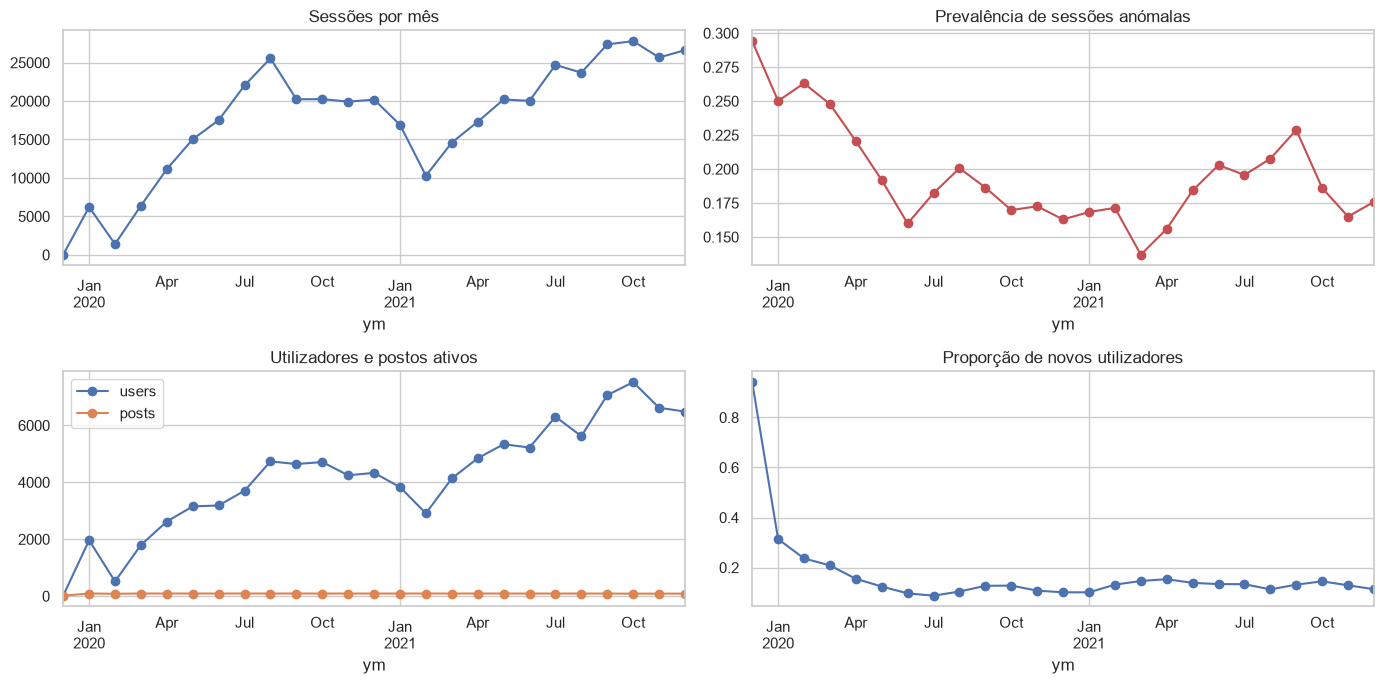

In [8]:
# ordenar cronologicamente pelo início da sessão (referência da predição)
df = df.sort_values("Start Time").reset_index(drop=True)
df["ym"] = df["Start Time"].dt.to_period("M")

print("Período:", df["Start Time"].min(), "→", df["Start Time"].max())

m = df.groupby("ym").agg(
    n=("is_Abnormal", "size"),
    abn_rate=("is_Abnormal", "mean"),
    users=("UserID", "nunique"),
    posts=("Charging Post ID", "nunique"),
    new_user_share=("is_new_user", "mean"),
    temp_mean=("Temperature(℃)", "mean"),
    temp_min=("Temperature(℃)", "min"),
)
display(m.round(3))

fig, ax = plt.subplots(2, 2, figsize=(14, 7))
m["n"].plot(ax=ax[0, 0], marker="o", title="Sessões por mês")
m["abn_rate"].plot(ax=ax[0, 1], marker="o", color="C3", title="Prevalência de sessões anómalas")
m[["users", "posts"]].plot(ax=ax[1, 0], marker="o", title="Utilizadores e postos ativos")
m["new_user_share"].plot(ax=ax[1, 1], marker="o", title="Proporção de novos utilizadores")
plt.tight_layout()
plt.show()

### 4.1 Estabilidade temporal dos preditores e cobertura do histórico
Evolução mensal da cobertura do histórico (arranque a frio) e de preditores disponíveis no início da sessão, e relação sazonal entre temperatura e prevalência.

,post_sem_hist,user_sem_hist,user_sem_hist_abn,post_sessions_7D,post_abn_rate_30D,user_sessions_30D,user_abn_rate_730D,active_at_start,price
ym,,,,,,,,,
2019-12,1.000,1.000,1.000,0.000,0.200,0.000,0.200,0.059,0.440
2020-01,0.012,0.321,0.551,25.170,0.243,13.784,0.231,0.079,0.769
2020-02,0.000,0.238,0.421,8.182,0.231,19.133,0.252,0.067,0.785
2020-03,0.000,0.212,0.426,26.986,0.257,26.397,0.241,0.089,0.784
2020-04,0.000,0.156,0.363,46.470,0.231,45.716,0.225,0.081,0.771
2020-05,0.000,0.126,0.311,57.276,0.195,79.493,0.208,0.202,0.763
2020-06,0.000,0.098,0.270,61.535,0.175,309.163,0.195,0.710,0.719
2020-07,0.000,0.088,0.240,68.958,0.168,168.601,0.189,0.216,0.717
2020-08,0.000,0.105,0.236,84.633,0.199,36.145,0.200,0.020,0.742


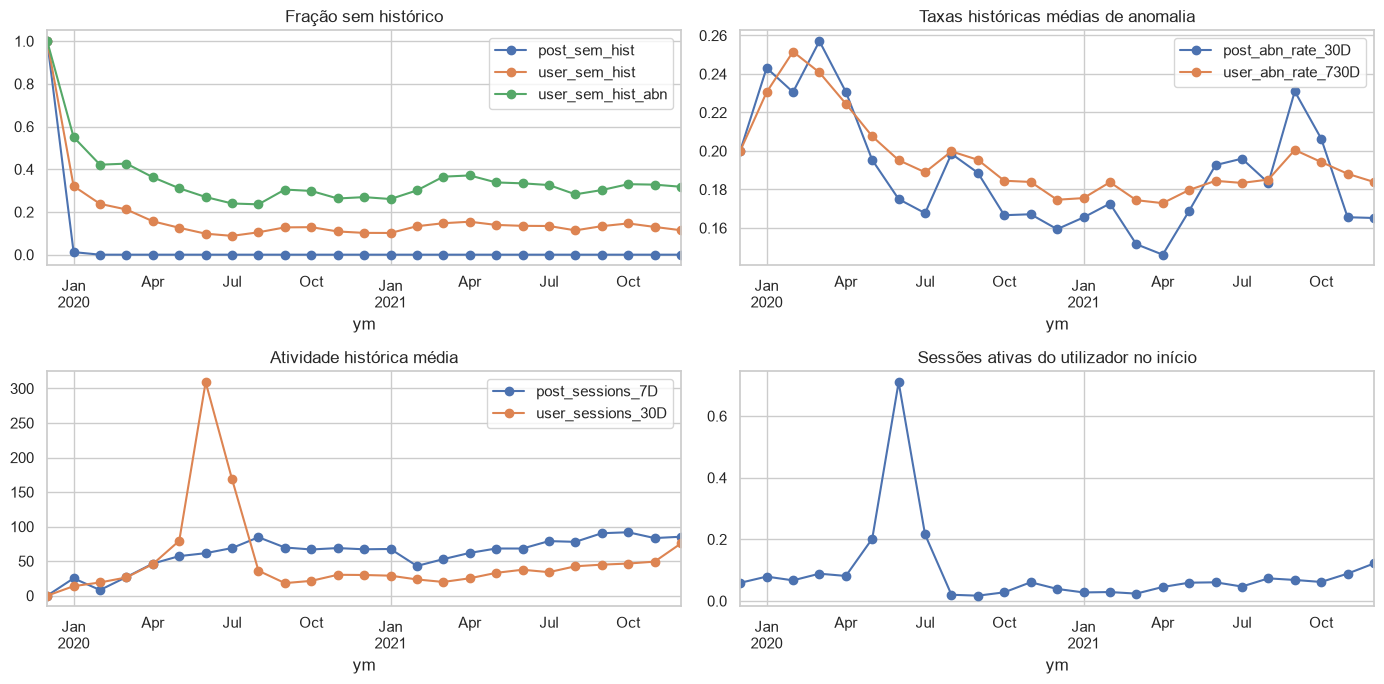

Correlação (temp_mean, abn_rate): 0.037
Correlação (n, abn_rate): -0.452


In [9]:
cov = df.groupby("ym").agg(
    post_sem_hist=("post_no_previous_completed_session", "mean"),
    user_sem_hist=("user_no_previous_completed_session", "mean"),
    user_sem_hist_abn=("user_no_previous_completed_abnormal", "mean"),
    post_sessions_7D=("post_previous_sessions_7D", "mean"),
    post_abn_rate_30D=("post_previous_abnormal_rate_30D", "mean"),
    user_sessions_30D=("user_previous_sessions_30D", "mean"),
    user_abn_rate_730D=("user_previous_abnormal_rate_730D", "mean"),
    active_at_start=("user_active_sessions_at_start", "mean"),
    price=("electricity_price", "mean"),
)
display(cov.round(3))

fig, ax = plt.subplots(2, 2, figsize=(14, 7))
cov[["post_sem_hist", "user_sem_hist", "user_sem_hist_abn"]].plot(ax=ax[0, 0], marker="o", title="Fração sem histórico")
cov[["post_abn_rate_30D", "user_abn_rate_730D"]].plot(ax=ax[0, 1], marker="o", title="Taxas históricas médias de anomalia")
cov[["post_sessions_7D", "user_sessions_30D"]].plot(ax=ax[1, 0], marker="o", title="Atividade histórica média")
cov["active_at_start"].plot(ax=ax[1, 1], marker="o", title="Sessões ativas do utilizador no início")
plt.tight_layout()
plt.show()

# sazonalidade: temperatura média mensal vs prevalência (sem dez/2019, só 17 sessões)
mm = m.iloc[1:]
print("Correlação (temp_mean, abn_rate):", round(mm["abn_rate"].corr(mm["temp_mean"]), 3))
print("Correlação (n, abn_rate):", round(mm["n"].corr(mm["abn_rate"]), 3))

### 4.2 Investigação do pico de atividade de utilizadores (mai–jul/2020)
A média mensal de `user_previous_sessions_30D` e `user_active_sessions_at_start` dispara em mai–jul/2020. Verificar se é causado por poucas contas muito ativas e como se relacionam com o alvo.

In [10]:
# perfil por utilizador
uc = df.groupby("UserID").agg(
    n=("is_Abnormal", "size"),
    abn=("is_Abnormal", "mean"),
    first=("Start Time", "min"),
    last=("Start Time", "max"),
    posts=("Charging Post ID", "nunique"),
)
uc["share"] = uc["n"] / len(df)
print("Utilizadores:", len(uc), "| mediana sessões:", uc["n"].median(), "| p99:", uc["n"].quantile(.99))
print("Quota das sessões dos top 10 utilizadores:", uc["share"].nlargest(10).sum().round(4))
display(uc.sort_values("n", ascending=False).head(10).round(3))

# sessões mensais dos 5 utilizadores mais ativos
top_users = uc["n"].nlargest(5).index
display(df[df["UserID"].isin(top_users)].groupby(["ym", "UserID"]).size().unstack(fill_value=0))

# quem tem o máximo de histórico/concorrência no pico?
pk = df[df["ym"].between("2020-05", "2020-07")]
display(pk.nlargest(5, "user_previous_sessions_30D")[
    ["UserID", "Start Time", "user_previous_sessions_30D", "user_active_sessions_at_start", "is_Abnormal"]])

# concorrência vs alvo
bins = [-1, 0, 1, 2, 5, 1000]
print(df.groupby(pd.cut(df["user_active_sessions_at_start"], bins))["is_Abnormal"]
        .agg(n="size", abnormal="mean").round(3))

Utilizadores: 56115 | mediana sessões: 2.0 | p99: 126.0
Quota das sessões dos top 10 utilizadores: 0.0655


C:\Users\inesm\AppData\Local\Temp\ipykernel_57900\2377055656.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(uc.sort_values("n", ascending=False).head(10).round(3))


,n,abn,first,last,posts,share
UserID,,,,,,
39,14584,0.158,2020-01-01 03:05:53,2021-12-31 21:38:35,92,0.033
23,6748,0.145,2020-09-18 13:34:14,2021-12-31 22:22:56,92,0.015
1087,1094,0.174,2020-01-01 00:12:32,2021-12-31 10:25:10,48,0.002
1457,995,0.154,2020-03-30 18:56:36,2021-12-31 10:25:47,58,0.002
7841,994,0.121,2020-04-16 15:42:52,2021-12-16 07:03:51,42,0.002
520,983,0.208,2020-09-18 03:31:53,2021-12-31 22:38:01,48,0.002
604,900,0.359,2020-05-18 21:00:57,2021-12-31 07:51:03,30,0.002
4990,895,0.082,2020-03-07 19:04:22,2021-12-30 15:49:49,18,0.002
3679,842,0.163,2020-03-10 09:53:29,2021-12-29 21:43:16,54,0.002


UserID,23,39,1087,1457,7841
ym,,,,,
2020-01,0,327,13,0,0
2020-02,0,129,0,0,0
2020-03,0,447,0,3,0
2020-04,0,663,34,55,31
2020-05,0,1172,76,42,68
2020-06,0,2597,68,48,71
2020-07,0,1339,61,58,80
2020-08,0,267,66,70,73
2020-09,53,136,78,12,51


,UserID,Start Time,user_previous_sessions_30D,user_active_sessions_at_start,is_Abnormal
57478,39,2020-06-30 17:08:34,2605,3,0
57467,39,2020-06-30 16:49:30,2603,5,0
57508,39,2020-06-30 18:18:55,2603,0,0
57512,39,2020-06-30 18:24:28,2603,1,0
57465,39,2020-06-30 16:46:51,2602,5,0


                                    n  abnormal
user_active_sessions_at_start                  
(-1, 0]                        420500     0.185
(0, 1]                          11718     0.238
(1, 2]                           3799     0.165
(2, 5]                           3907     0.139
(5, 1000]                        1153     0.138


### 4.3 Decisão sobre contas de muito alta atividade
UserID 39 e 23 (≈4,8% das sessões) explicam o pico de `user_previous_sessions_30D` e `user_active_sessions_at_start`. Prevalência semelhante à global.
Decisão: manter as sessões; tratar extremos dos preditores `user_*` na preparação (cap/log, ajustados só no treino); excluir `UserID` como preditor.
## 5. Split cronológico
Treino: dez/2019–jun/2021 · Validação: jul–set/2021 · Teste: out–dez/2021. O split é feito antes de qualquer operação que aprenda com os dados.

In [11]:
train_end = pd.Period("2021-06", "M")
val_end = pd.Period("2021-09", "M")

train = df[df["ym"] <= train_end].copy()
val = df[(df["ym"] > train_end) & (df["ym"] <= val_end)].copy()
test = df[df["ym"] > val_end].copy()

for nome, d in [("treino", train), ("validação", val), ("teste", test)]:
    print(f"{nome:10s} n={len(d):7d} ({len(d)/len(df):.1%}) | "
          f"{d['Start Time'].min().date()} → {d['Start Time'].max().date()} | "
          f"prevalência={d['is_Abnormal'].mean():.4f}")

# cold-start: utilizadores/postos de val/test nunca vistos no treino
for nome, d in [("validação", val), ("teste", test)]:
    print(f"\n{nome}:")
    print("  sessões de utilizadores não vistos no treino:",
          round((~d["UserID"].isin(train["UserID"])).mean(), 3))
    print("  sessões de postos não vistos no treino:",
          round((~d["Charging Post ID"].isin(train["Charging Post ID"])).mean(), 3))
    print("  quota das contas 39 e 23:", round(d["UserID"].isin([39, 23]).mean(), 3))
print("\nquota das contas 39 e 23 no treino:", round(train["UserID"].isin([39, 23]).mean(), 3))

treino     n= 285227 (64.7%) | 2019-12-31 → 2021-06-30 | prevalência=0.1817
validação  n=  75769 (17.2%) | 2021-07-01 → 2021-09-30 | prevalência=0.2114
teste      n=  80081 (18.2%) | 2021-10-01 → 2021-12-31 | prevalência=0.1759

validação:
  sessões de utilizadores não vistos no treino: 0.398
  sessões de postos não vistos no treino: 0.0
  quota das contas 39 e 23: 0.045

teste:
  sessões de utilizadores não vistos no treino: 0.612
  sessões de postos não vistos no treino: 0.0
  quota das contas 39 e 23: 0.058

quota das contas 39 e 23 no treino: 0.046


### 5.1 Resultado do split e cold-start
Prevalência: treino 18,2% · validação 21,1% · teste 17,6%. Postos: sem cold-start. Utilizadores: 40% (val) e 61% (teste) das sessões são de contas não vistas no treino → `UserID` excluído; generalização dependente dos atributos `user_*`.
## 6. Preditores candidatos: distribuições e outliers (apenas treino)
Features temporais derivadas de `Start Time`: `hour`, `dow`, `is_weekend` (sem `month`: só 2 anos de dados).

In [12]:
# features temporais (derivação determinística, sem aprender dos dados)
df["hour"] = df["Start Time"].dt.hour
df["dow"] = df["Start Time"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

train = df[df["ym"] <= train_end].copy()
val = df[(df["ym"] > train_end) & (df["ym"] <= val_end)].copy()
test = df[df["ym"] > val_end].copy()

# grupos de preditores candidatos (disponíveis no início da sessão)
WEATHER = ["Temperature(℃)", "Relative Humidity(%)", "Precipitation(mm)"]
TARIFF = ["electricity_price"]
TIME = ["hour", "dow", "is_weekend"]
HIST_POST = [c for c in df.columns if c.startswith("post_")]
HIST_USER = [c for c in df.columns if c.startswith("user_") or c == "is_new_user"]
NUM_FEATS = WEATHER + TARIFF + TIME + HIST_POST + HIST_USER

BINARY = [c for c in NUM_FEATS if train[c].nunique() <= 2]
CONT = [c for c in NUM_FEATS if c not in BINARY]
print(len(NUM_FEATS), "numéricos |", len(BINARY), "binários |", len(CONT), "contínuos/contagens")

# resumo no treino
s = train[CONT].describe(percentiles=[.01, .5, .99]).T[["min", "1%", "50%", "99%", "max"]]
s["skew"] = train[CONT].skew()
s["zeros"] = (train[CONT] == 0).mean()
s["nan"] = train[CONT].isna().mean()
s["max/p99"] = s["max"] / s["99%"].replace(0, np.nan)
display(s.round(3))

# binários: frequência de 1 no treino
display(train[BINARY].mean().round(3).to_frame("frac_1"))

35 numéricos | 6 binários | 29 contínuos/contagens


,min,1%,50%,99%,max,skew,zeros,nan,max/p99
Temperature(℃),-3.200,0.700,20.100,32.300,32.700,-0.395,0.000,0.000,1.012
Relative Humidity(%),32.000,41.000,76.000,98.000,99.000,-0.500,0.000,0.000,1.010
Precipitation(mm),0.000,0.000,0.000,36.200,152.100,6.844,0.535,0.000,4.202
electricity_price,0.378,0.378,0.901,1.206,1.206,-0.263,0.000,0.000,1.000
hour,0.000,0.000,15.000,23.000,23.000,-0.563,0.025,0.000,1.000
dow,0.000,0.000,3.000,6.000,6.000,-0.033,0.139,0.000,1.000
post_previous_sessions_1D,0.000,0.000,9.000,29.000,75.000,1.338,0.017,0.000,2.586
post_previous_abnormal_1D,0.000,0.000,1.000,22.000,75.000,5.380,0.447,0.000,3.409
post_previous_abnormal_rate_1D,0.030,0.043,0.143,0.818,0.950,2.166,0.000,0.000,1.161
post_previous_sessions_7D,0.000,5.000,63.000,140.000,254.000,0.380,0.001,0.000,1.814


,frac_1
is_weekend,0.290
post_no_previous_completed_session,0.000
post_no_previous_completed_abnormal,0.001
is_new_user,0.127
user_no_previous_completed_session,0.128
user_no_previous_completed_abnormal,0.306


### 6.1 Distribuições, assimetria e candidatos a transformação
Variáveis meteorológicas e tarifárias sem problemas. `hour`/`dow`: zeros válidos. Assimetria forte nas contagens, nos tempos desde a última sessão e na precipitação. O p99 dos preditores `user_*` pode estar contaminado pelas contas 39 e 23: verificar antes de usar caps por percentil.

post_no_previous_completed_session      92
post_no_previous_completed_abnormal    367
dtype: int64

user_previous_sessions_30D > p99 (1859): 2852 sessões | quota das contas 39/23: 1.000

Precipitação > 10 mm: 0.0903 | > 50 mm: 1258
                        n  abnormal
Precipitation(mm)                  
(-1.0, 0.0]        152472     0.186
(0.0, 0.5]          39717     0.175
(0.5, 2.0]          28008     0.179
(2.0, 10.0]         39277     0.179
(10.0, 40.0]        23895     0.171
(40.0, 200.0]        1858     0.205


,skew,skew_log1p
Relative Humidity(%),-0.50,-1.06
Precipitation(mm),6.84,1.63
electricity_price,-0.26,-0.39
post_previous_sessions_1D,1.34,-0.94
post_previous_abnormal_1D,5.38,1.12
post_previous_abnormal_rate_1D,2.17,1.74
post_previous_sessions_7D,0.38,-1.47
post_previous_abnormal_7D,4.37,0.24
post_previous_abnormal_rate_7D,2.24,1.76
post_previous_sessions_30D,0.11,-1.78


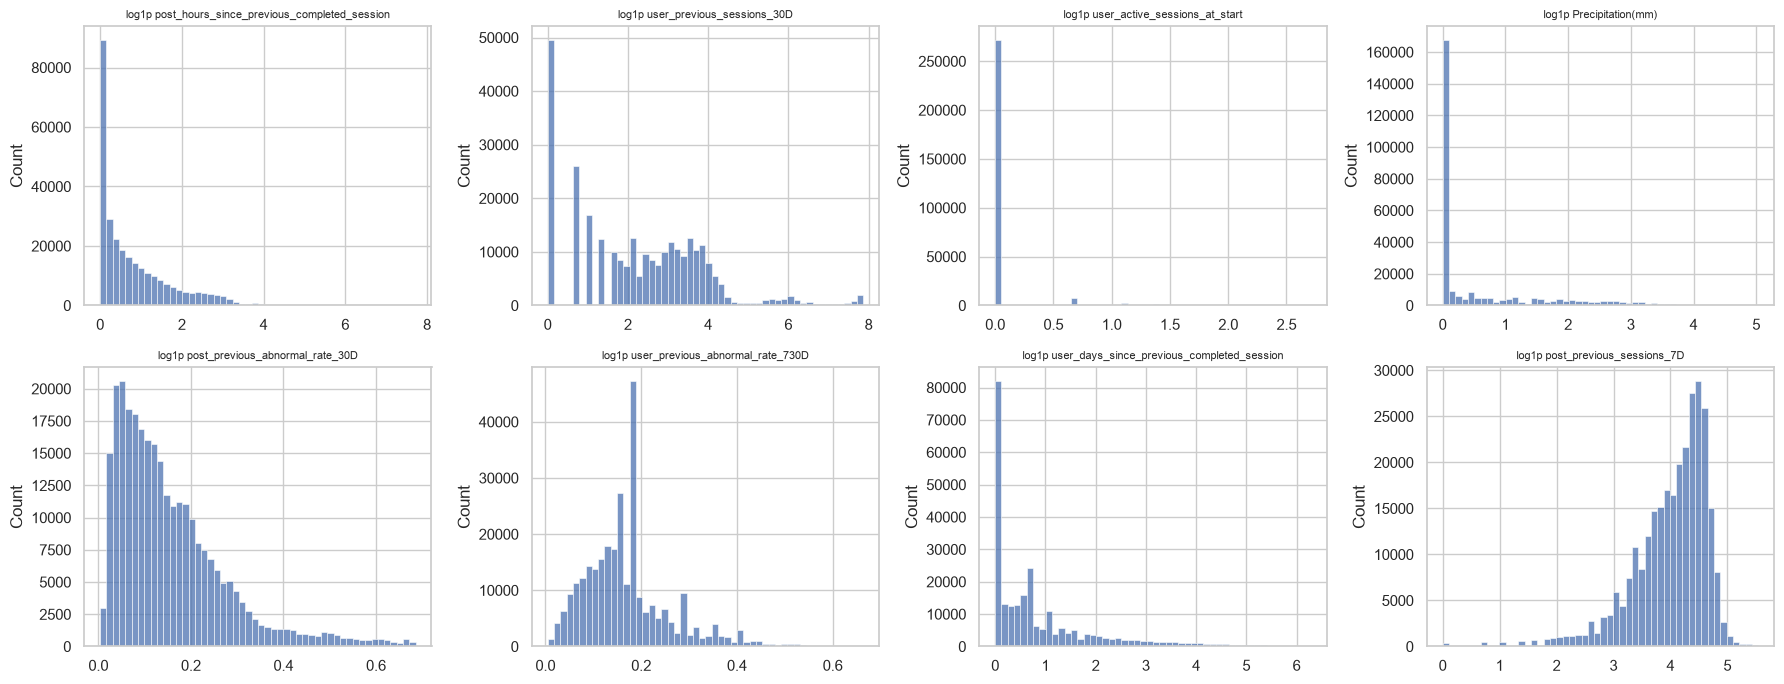

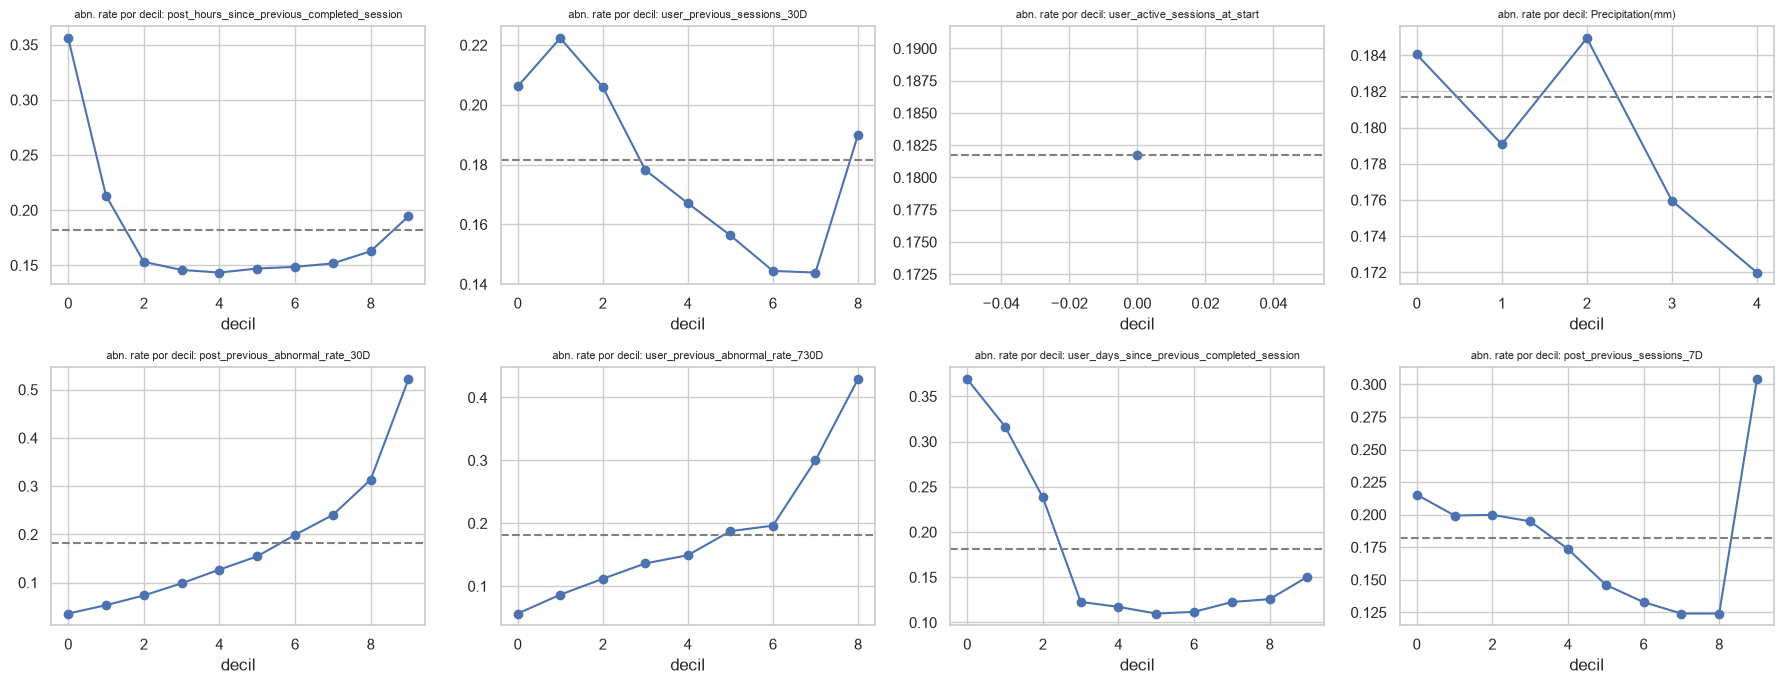

In [13]:
# 1) binários quase constantes (nº de sessões com flag = 1 no treino)
print(train[["post_no_previous_completed_session", "post_no_previous_completed_abnormal"]].sum())

# 2) p99 de user_previous_sessions_30D contaminado pelas contas 39/23?
col = "user_previous_sessions_30D"
thr = train[col].quantile(.99)
top = train[col] > thr
print(f"\n{col} > p99 ({thr:.0f}): {top.sum()} sessões | quota das contas 39/23: "
      f"{train.loc[top, 'UserID'].isin([39, 23]).mean():.3f}")

# 3) precipitação vs alvo
p = train["Precipitation(mm)"]
print("\nPrecipitação > 10 mm:", (p > 10).mean().round(4), "| > 50 mm:", (p > 50).sum())
print(train.groupby(pd.cut(p, [-1, 0, 0.5, 2, 10, 40, 200]), observed=True)["is_Abnormal"]
        .agg(n="size", abnormal="mean").round(3))

# 4) skew antes e depois de log1p (contínuas não negativas, sem as temporais)
nonneg = [c for c in CONT if c not in TIME and train[c].min() >= 0]
sk = pd.DataFrame({"skew": train[nonneg].skew(), "skew_log1p": np.log1p(train[nonneg]).skew()})
display(sk.round(2))

# 5) distribuições (log1p) e taxa de anómalas por decil
KEY = ["post_hours_since_previous_completed_session", "user_previous_sessions_30D",
       "user_active_sessions_at_start", "Precipitation(mm)",
       "post_previous_abnormal_rate_30D", "user_previous_abnormal_rate_730D",
       "user_days_since_previous_completed_session", "post_previous_sessions_7D"]

fig, ax = plt.subplots(2, 4, figsize=(18, 7))
for a, c in zip(ax.ravel(), KEY):
    sns.histplot(np.log1p(train[c].dropna()), bins=50, ax=a)
    a.set_title("log1p " + c, fontsize=8); a.set_xlabel("")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(2, 4, figsize=(18, 7))
for a, c in zip(ax.ravel(), KEY):
    q = pd.qcut(train[c], 10, duplicates="drop")
    train.groupby(q, observed=True)["is_Abnormal"].mean().reset_index(drop=True).plot(ax=a, marker="o")
    a.axhline(train["is_Abnormal"].mean(), color="gray", ls="--")
    a.set_title("abn. rate por decil: " + c, fontsize=8); a.set_xlabel("decil")
plt.tight_layout(); plt.show()

### 6.2 Decisões sobre variáveis numéricas
- p99 de `user_previous_sessions_30D` contaminado pelas contas 39/23 → log1p em vez de cap por percentil.
- Sinal forte e não linear nas taxas históricas e nos tempos desde a sessão anterior (mais anomalias quando a sessão anterior é muito recente).
- `Precipitation(mm)`: sinal fraco, log1p. `user_active_sessions_at_start`: cap em 3.
- Taxas históricas (limitadas a [0,1]) ficam sem transformação.

In [14]:
# 1) flags de postos sem histórico: só existem no arranque?
for c in ["post_no_previous_completed_session", "post_no_previous_completed_abnormal"]:
    meses = df.loc[df[c] == 1, "ym"].astype(str)
    print(c, "| treino:", train[c].sum(), "| val:", val[c].sum(), "| teste:", test[c].sum(),
          "| primeiro/último mês com flag=1:", meses.min(), "/", meses.max())

# 2) post_previous_sessions_7D: o que há no topo da distribuição?
c = "post_previous_sessions_7D"
q = train[c].quantile([.8, .9, .95, .99])
print("\nQuantis:", q.round(0).to_dict())
faixa = pd.cut(train[c], [-1, q[.8], q[.9], q[.95], q[.99], train[c].max()])
print(train.groupby(faixa, observed=True)["is_Abnormal"].agg(n="size", abnormal="mean").round(3))

top = train[c] > q[.9]
print("\nSessões no topo por mês:")
print(train[top].groupby("ym")["is_Abnormal"].agg(n="size", abnormal="mean").round(3))
print("\nTop 5 postos no topo:")
print(train[top].groupby("Charging Post ID")["is_Abnormal"].agg(n="size", abnormal="mean")
      .sort_values("n", ascending=False).head(5).round(3))

post_no_previous_completed_session | treino: 92 | val: 0 | teste: 0 | primeiro/último mês com flag=1: 2019-12 / 2020-01
post_no_previous_completed_abnormal | treino: 367 | val: 0 | teste: 0 | primeiro/último mês com flag=1: 2019-12 / 2020-03

Quantis: {0.8: 92.0, 0.9: 104.0, 0.95: 115.0, 0.99: 140.0}
                                n  abnormal
post_previous_sessions_7D                  
(-1.0, 92.0]               228472     0.174
(92.0, 104.0]               28742     0.124
(104.0, 115.0]              14188     0.191
(115.0, 140.0]              11075     0.350
(140.0, 254.0]               2750     0.699

Sessões no topo por mês:
            n  abnormal
ym                     
2020-03    29     0.310
2020-04  1481     0.354
2020-05  2133     0.342
2020-06  2107     0.186
2020-07  2062     0.283
2020-08  7372     0.233
2020-09  1617     0.506
2020-10   891     0.442
2020-11  1709     0.195
2020-12  1458     0.214
2021-01  1694     0.198
2021-04  1181     0.390
2021-05  2461     0.399
2021

## 7. Variáveis categóricas (apenas treino)
Cardinalidade, redundância entre posto/localização/distrito, categorias raras, relação com o alvo e estabilidade da taxa por posto entre treino e validação.

In [15]:
CATS = ["Charging Post ID", "Location Information", "District Name", "tariff_period"]
print(train[CATS].nunique())

# redundância: um posto pertence a uma só localização/distrito?
print("\nMax. de localizações/distritos distintos por posto:")
print(train.groupby("Charging Post ID")[["Location Information", "District Name"]].nunique().max())
print("Postos por localização (mediana/máx):",
      train.groupby("Location Information")["Charging Post ID"].nunique().agg(["median", "max"]).to_dict())

for c in ["District Name", "tariff_period", "Location Information"]:
    print(f"\n{c}")
    display(train.groupby(c)["is_Abnormal"].agg(n="size", abnormal="mean")
            .sort_values("n", ascending=False).round(3))

# dispersão por posto
pp = train.groupby("Charging Post ID")["is_Abnormal"].agg(n="size", abnormal="mean")
print("\nSessões por posto:"); display(pp["n"].describe().round(0).to_frame().T)
print("Taxa de anómalas por posto:"); display(pp["abnormal"].describe().round(3).to_frame().T)
print("Postos com < 200 sessões no treino:", (pp["n"] < 200).sum())
display(pp.sort_values("abnormal", ascending=False).head(8).round(3))

# a taxa por posto é estável no tempo? (treino vs validação)
pv = val.groupby("Charging Post ID")["is_Abnormal"].mean()
print("Correlação da taxa por posto (treino vs validação):", round(pp["abnormal"].corr(pv), 3))

Charging Post ID        92
Location Information    13
District Name            3
tariff_period            7
dtype: int64

Max. de localizações/distritos distintos por posto:
Location Information    1
District Name           1
dtype: int64
Postos por localização (mediana/máx): {'median': 8.0, 'max': 8.0}

District Name


,n,abnormal
District Name,,
Tongxiang,146535,0.147
Xiuzhou,88428,0.244
Nanhu,50264,0.172



tariff_period


,n,abnormal
tariff_period,,
peak_13_19,108517,0.191
off_peak_11_13,40038,0.206
peak_08_11,31404,0.174
sharp_19_21,31327,0.163
off_peak_00_08,30025,0.172
off_peak_22_24,28974,0.165
peak_21_22,14942,0.160



Location Information


...

Taxa de anómalas por posto:


,count,mean,std,min,25%,50%,75%,max
abnormal,92.0,0.195,0.111,0.044,0.099,0.174,0.272,0.596


Postos com < 200 sessões no treino: 0


,n,abnormal
Charging Post ID,,
75,2607,0.596
24,3951,0.435
73,606,0.409
27,4427,0.407
15,1628,0.402
90,2545,0.396
16,819,0.382
28,4966,0.378


Correlação da taxa por posto (treino vs validação): 0.73


### 6.3 Decisões sobre flags e `post_previous_sessions_7D`
- `post_no_previous_completed_session/abnormal`: só no arranque (dez/2019–mar/2020), nulas em validação e teste → excluídas. NaN restantes de `post_hours_since_*` imputados no treino.
- `post_previous_sessions_7D`: relação não linear (70% de anómalas acima de 140 sessões/7D, concentrada em episódios) → sem cap.

### 7.1 Decisões sobre categóricas
Sem categorias raras (posto mínimo: 253 sessões). Posto → localização → distrito (hierarquia). Taxa por posto estável (corr. treino–validação = 0,73). `UserID` excluído.
## 8. Relações com o alvo (treino; validação só para verificar estabilidade)

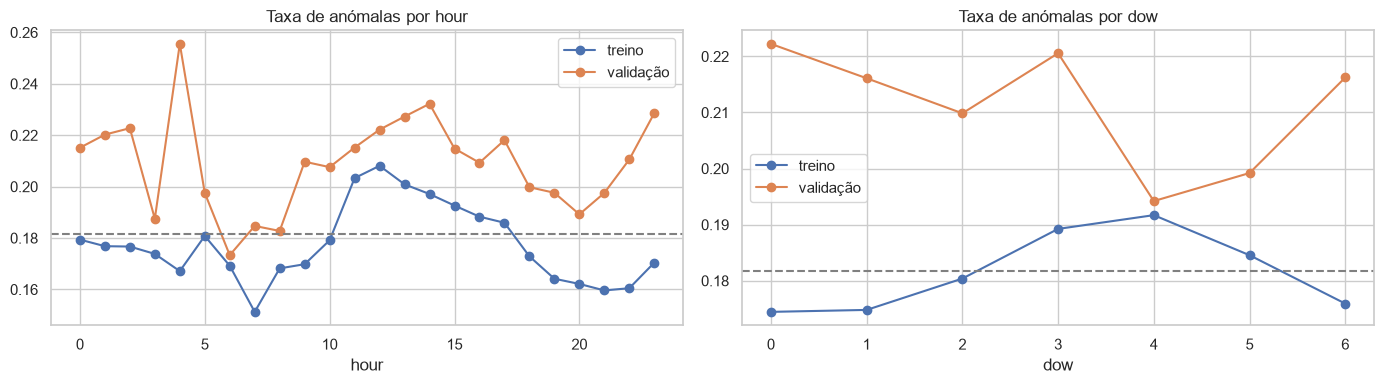


Temperature(℃)
                treino  validação
Temperature(℃)                   
(-inf, 7.5]      0.188        NaN
(7.5, 10.6]      0.161        NaN
(10.6, 14.4]     0.178        NaN
(14.4, 17.5]     0.179        NaN
(17.5, 20.1]     0.171        NaN
(20.1, 22.7]     0.177        NaN
(22.7, 25.1]     0.188      0.208
(25.1, 26.7]     0.183      0.203
(26.7, 29.4]     0.181      0.213
(29.4, inf]      0.211      0.215

Relative Humidity(%)
                      treino  validação
Relative Humidity(%)                   
(-inf, 58.0]           0.184      0.202
(58.0, 64.0]           0.186      0.195
(64.0, 69.0]           0.184      0.222
(69.0, 74.0]           0.182      0.212
(74.0, 76.0]           0.179      0.224
(76.0, 80.0]           0.185      0.222
(80.0, 84.0]           0.177      0.204
(84.0, 88.0]           0.182      0.199
(88.0, 93.0]           0.179      0.206
(93.0, inf]            0.178      0.185

Períodos tarifários distintos por hora (máx): 1

Preço por período tarifá

In [16]:
base = train["is_Abnormal"].mean()

# hora e dia da semana: treino vs validação
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, c in zip(ax, ["hour", "dow"]):
    train.groupby(c)["is_Abnormal"].mean().plot(ax=a, marker="o", label="treino")
    val.groupby(c)["is_Abnormal"].mean().plot(ax=a, marker="o", label="validação")
    a.axhline(base, color="gray", ls="--"); a.set_title("Taxa de anómalas por " + c); a.legend()
plt.tight_layout(); plt.show()

# temperatura e humidade por decil (limites do treino)
for c in ["Temperature(℃)", "Relative Humidity(%)"]:
    q = pd.qcut(train[c], 10, duplicates="drop", retbins=True)[1]
    q[0], q[-1] = -np.inf, np.inf
    print("\n" + c)
    print(pd.DataFrame({
        "treino": train.groupby(pd.cut(train[c], q), observed=True)["is_Abnormal"].mean(),
        "validação": val.groupby(pd.cut(val[c], q), observed=True)["is_Abnormal"].mean(),
    }).round(3))

# redundância: tarifa vs hora vs preço
print("\nPeríodos tarifários distintos por hora (máx):", train.groupby("hour")["tariff_period"].nunique().max())
print("\nPreço por período tarifário:")
print(train.groupby("tariff_period")["electricity_price"].agg(["nunique", "min", "max"]).round(3))

In [17]:
from sklearn.metrics import roc_auc_score

GROUPS = {"weather": WEATHER, "tariff": TARIFF, "time": TIME,
          "hist_post": HIST_POST, "hist_user": HIST_USER}
rows = []
for g, cols in GROUPS.items():
    for c in cols:
        med = train[c].median()
        rows.append((g, c,
                     roc_auc_score(train["is_Abnormal"], train[c].fillna(med)),
                     roc_auc_score(val["is_Abnormal"], val[c].fillna(med))))
auc = pd.DataFrame(rows, columns=["grupo", "var", "AUC_treino", "AUC_val"])
auc["força_treino"] = (auc["AUC_treino"] - .5).abs() * 2
auc["mesmo_sentido"] = (auc["AUC_treino"] - .5) * (auc["AUC_val"] - .5) > 0
display(auc.sort_values("força_treino", ascending=False).round(3).reset_index(drop=True))

# força média por grupo
print(auc.groupby("grupo")["força_treino"].agg(["mean", "max"]).round(3))

# correlações (Spearman, amostra de 100k do treino) entre preditores numéricos
cm = train[NUM_FEATS].sample(100_000, random_state=42).corr(method="spearman").abs()
pairs = cm.where(np.triu(np.ones(cm.shape), 1).astype(bool)).stack().sort_values(ascending=False)
print("\nPares com |rho| > 0.95:", (pairs > 0.95).sum(), "| > 0.90:", (pairs > 0.90).sum())
display(pairs.head(20).round(3).to_frame("|rho|"))

,grupo,var,AUC_treino,AUC_val,força_treino,mesmo_sentido
0,hist_post,post_previous_abnormal_rate_7D,0.765,0.788,0.531,True
1,hist_post,post_previous_abnormal_rate_1D,0.758,0.786,0.517,True
2,hist_post,post_previous_abnormal_rate_30D,0.752,0.769,0.503,True
3,hist_post,post_hours_since_previous_completed_abnormal,0.274,0.240,0.451,True
4,hist_post,post_previous_abnormal_1D,0.719,0.771,0.438,True
5,hist_post,post_previous_abnormal_7D,0.717,0.772,0.434,True
6,hist_user,user_previous_abnormal_rate_30D,0.695,0.686,0.390,True
7,hist_post,post_previous_abnormal_30D,0.690,0.749,0.379,True
8,hist_user,user_previous_abnormal_rate_180D,0.687,0.685,0.373,True
9,hist_user,user_previous_abnormal_rate_730D,0.685,0.681,0.370,True


            mean    max
grupo                  
hist_post  0.270  0.531
hist_user  0.161  0.390
tariff     0.013  0.013
time       0.013  0.026
weather    0.016  0.026

Pares com |rho| > 0.95: 4 | > 0.90: 6


|rho|
is_new_user                      user_no_previous_completed_session            0.994
user_previous_sessions_180D      user_previous_sessions_730D                   0.989
user_previous_abnormal_180D      user_previous_abnormal_730D                   0.973
user_previous_abnormal_rate_180D user_previous_abnormal_rate_730D              0.970
post_previous_sessions_7D        post_previous_sessions_30D                    0.913
user_previous_sessions_30D       user_previous_sessions_180D                   0.909
user_previous_sessions_730D      user_previous_abnormal_730D                   0.887
user_previous_sessions_30D       user_previous_sessions_730D                   0.880
user_previous_sessions_180D      user_previous_abnormal_730D                   0.876
                                 user_previous_abnormal_180D                   0.869
post_previous_abnormal_1D        post_hours_since_previous_completed_abnormal  0.854
user_previous_abnormal_180D      user_previous_sessions_730D                   0.852
post_previous_abnormal_rate_7D   post_previous_abnormal_rate_30D               0.846
post_previous_abnormal_1D        post_previous_abnormal_rate_1D                0.838
user_previous_abnormal_30D       user_previous_abnormal_180D                   0.826
post_previous_sessions_1D        post_previous_sessions_7D                     0.821
user_previous_abnormal_730D      user_no_previous_completed_abnormal           0.810
user_previous_abnormal_rate_30D  user_previous_abnormal_rate_180D              0.809
post_previous_abnormal_7D        post_previous_abnormal_rate_7D                0.807
user_previous_sessions_30D       user_previous_abnormal_180D                   0.802

### 8.1 Decisões de variáveis (força univariada, estabilidade e redundância)
- Grupos fortes: históricos do posto (AUC até 0,79) e do utilizador (até 0,69). Meteorologia, hora/dia e tarifa: sinal quase nulo; mantidos como grupos para ablação.
- `dow` instável entre treino e validação; `is_weekend` excluída (derivada de `dow`).
- `tariff_period` e `electricity_price` são funções determinísticas de `hour` → `tariff_period` excluída.
- Redundância: `is_new_user` ≈ `user_no_previous_completed_session` (ρ=0,99); janelas 730D ≈ 180D (ρ≥0,97) → excluídas `is_new_user` e as variáveis 730D.
- Hierarquia posto → localização → distrito (granularidade a decidir na ablação).
## 9. Preparação dos dados

In [18]:
DROP_FLAGS = ["post_no_previous_completed_session", "post_no_previous_completed_abnormal"]
DROP_REDUND = ["is_new_user", "user_previous_sessions_730D",
               "user_previous_abnormal_730D", "user_previous_abnormal_rate_730D"]

FEATURE_GROUPS = {
    "weather": WEATHER,
    "tariff": ["electricity_price"],
    "time": ["hour", "dow"],
    "hist_post": [c for c in HIST_POST if c not in DROP_FLAGS],
    "hist_user": [c for c in HIST_USER if c not in DROP_REDUND],
    "location": ["Charging Post ID", "Location Information", "District Name"],
}
for g, cols in FEATURE_GROUPS.items():
    print(f"{g:10s} ({len(cols)}):", cols)

CAT_FINAL = FEATURE_GROUPS["location"]
NUM_FINAL = [c for g, cols in FEATURE_GROUPS.items() if g != "location" for c in cols]
print("\nNuméricas:", len(NUM_FINAL), "| categóricas:", len(CAT_FINAL))

# valores em falta nas variáveis finais: fração por conjunto
nan_cols = [c for c in NUM_FINAL if df[c].isna().any()]
print("\nFração de NaN:")
print(pd.DataFrame({"treino": train[nan_cols].isna().mean(),
                    "val": val[nan_cols].isna().mean(),
                    "teste": test[nan_cols].isna().mean()}).round(3))

# taxa de anómalas quando o histórico não existe (NaN) vs existe
for c in nan_cols:
    print("\n" + c)
    print(train.groupby(train[c].isna())["is_Abnormal"].agg(n="size", abnormal="mean").round(3))

# nº de sessões por hora na validação (picos nocturnos)
print("\nSessões por hora na validação (3h-5h):", val.groupby("hour").size().loc[[3, 4, 5]].to_dict())

weather    (3): ['Temperature(℃)', 'Relative Humidity(%)', 'Precipitation(mm)']
tariff     (1): ['electricity_price']
time       (2): ['hour', 'dow']
hist_post  (11): ['post_previous_sessions_1D', 'post_previous_abnormal_1D', 'post_previous_abnormal_rate_1D', 'post_previous_sessions_7D', 'post_previous_abnormal_7D', 'post_previous_abnormal_rate_7D', 'post_previous_sessions_30D', 'post_previous_abnormal_30D', 'post_previous_abnormal_rate_30D', 'post_hours_since_previous_completed_session', 'post_hours_since_previous_completed_abnormal']
hist_user  (11): ['user_previous_sessions_30D', 'user_previous_abnormal_30D', 'user_previous_abnormal_rate_30D', 'user_previous_sessions_180D', 'user_previous_abnormal_180D', 'user_previous_abnormal_rate_180D', 'user_days_since_previous_completed_session', 'user_no_previous_completed_session', 'user_days_since_previous_completed_abnormal', 'user_no_previous_completed_abnormal', 'user_active_sessions_at_start']
location   (3): ['Charging Post ID', 'Locati

### 9.1 Imputação de valores em falta
Os NaN restantes são estruturais e só ocorrem em `post_hours_since_*` (arranque) e `user_days_since_*` (sem histórico). A ausência é informativa e já está codificada nas flags `user_no_previous_completed_*`. Imputação pela mediana, ajustada apenas no treino.

In [19]:
from sklearn.impute import SimpleImputer

Xtr = train[NUM_FINAL].copy()
Xva = val[NUM_FINAL].copy()
Xte = test[NUM_FINAL].copy()

IMP_COLS = [c for c in NUM_FINAL if train[c].isna().any()]
imp = SimpleImputer(strategy="median").fit(Xtr[IMP_COLS])
print("Medianas do treino:")
print(pd.Series(imp.statistics_, index=IMP_COLS).round(3))

for X in (Xtr, Xva, Xte):
    X[IMP_COLS] = imp.transform(X[IMP_COLS])

print("\nNaN após imputação:", Xtr.isna().sum().sum(), Xva.isna().sum().sum(), Xte.isna().sum().sum())

Medianas do treino:
post_hours_since_previous_completed_session      0.612
post_hours_since_previous_completed_abnormal    20.166
user_days_since_previous_completed_session       0.708
user_days_since_previous_completed_abnormal      4.570
dtype: float64

NaN após imputação: 0 0 0


### 9.2 Transformações de assimetria e cap
- `log1p` (sem parâmetros aprendidos) em: precipitação, contagens de anomalias do posto, contagens do utilizador e tempos desde a sessão/anomalia anterior.
- `post_previous_sessions_*` e taxas históricas: sem transformação (log sobrecorrige; a relação com o alvo é não linear e o topo contém o sinal).
- `user_active_sessions_at_start`: cap em 3 (p99 do treino, não contaminado pelas contas 39/23).

In [20]:
LOG_COLS = ["Precipitation(mm)",
            "post_previous_abnormal_1D", "post_previous_abnormal_7D", "post_previous_abnormal_30D",
            "post_hours_since_previous_completed_session", "post_hours_since_previous_completed_abnormal",
            "user_previous_sessions_30D", "user_previous_abnormal_30D",
            "user_previous_sessions_180D", "user_previous_abnormal_180D",
            "user_days_since_previous_completed_session", "user_days_since_previous_completed_abnormal"]
CAP = {"user_active_sessions_at_start": 3}

assert all(Xtr[c].min() >= 0 for c in LOG_COLS), "log1p exige valores >= 0"
print("p99 treino de user_active_sessions_at_start:", train["user_active_sessions_at_start"].quantile(.99))

skew_antes = Xtr[LOG_COLS + list(CAP)].skew()
for X in (Xtr, Xva, Xte):
    for c, v in CAP.items():
        X[c] = X[c].clip(upper=v)
    X[LOG_COLS] = np.log1p(X[LOG_COLS])

print(pd.DataFrame({"skew_antes": skew_antes, "skew_depois": Xtr[LOG_COLS + list(CAP)].skew()}).round(2))
print("\nSessões com cap em user_active_sessions_at_start (treino/val/teste):",
      [(d["user_active_sessions_at_start"] > 3).mean().round(4) for d in (train, val, test)])

p99 treino de user_active_sessions_at_start: 3.0
                                              skew_antes  skew_depois
Precipitation(mm)                                   6.84         1.63
post_previous_abnormal_1D                           5.38         1.12
post_previous_abnormal_7D                           4.37         0.24
post_previous_abnormal_30D                          3.35        -0.06
post_hours_since_previous_completed_session        45.90         1.45
post_hours_since_previous_completed_abnormal        7.59        -0.17
user_previous_sessions_30D                          7.60         0.58
user_previous_abnormal_30D                          6.34         1.56
user_previous_sessions_180D                         6.45         0.35
user_previous_abnormal_180D                         6.00         1.10
user_days_since_previous_completed_session          8.34         1.98
user_days_since_previous_completed_abnormal         4.75         0.63
user_active_sessions_at_start            

### 9.3 Escalonamento
StandardScaler ajustado apenas no treino, aplicado a todas as variáveis numéricas não binárias. Flags binárias sem escalonamento. Guardam-se versões com e sem escalonamento (modelos de árvores dispensam-no).

In [21]:
from sklearn.preprocessing import StandardScaler

BIN_COLS = [c for c in NUM_FINAL if train[c].nunique() <= 2]
SCALE_COLS = [c for c in NUM_FINAL if c not in BIN_COLS]
print("Binárias (sem escalonamento):", BIN_COLS)
print("Escaladas:", len(SCALE_COLS))

scaler = StandardScaler().fit(Xtr[SCALE_COLS])
Xtr_s, Xva_s, Xte_s = Xtr.copy(), Xva.copy(), Xte.copy()
for X in (Xtr_s, Xva_s, Xte_s):
    X[SCALE_COLS] = scaler.transform(X[SCALE_COLS])

print("\nTreino: média/desvio (devem ser 0/1):")
print(Xtr_s[SCALE_COLS].agg(["mean", "std"]).T.round(2).describe().loc[["min", "max"]])
print("\nValidação e teste: maiores desvios da média (em unidades do treino):")
print(pd.DataFrame({"val": Xva_s[SCALE_COLS].mean(), "teste": Xte_s[SCALE_COLS].mean()})
        .abs().sort_values("teste", ascending=False).head(6).round(2))

Binárias (sem escalonamento): ['user_no_previous_completed_session', 'user_no_previous_completed_abnormal']
Escaladas: 26

Treino: média/desvio (devem ser 0/1):
     mean  std
min   0.0  1.0
max   0.0  1.0

Validação e teste: maiores desvios da média (em unidades do treino):
                             val  teste
post_previous_sessions_30D  0.52   0.81
post_previous_sessions_7D   0.59   0.72
Temperature(℃)              1.10   0.63
post_previous_sessions_1D   0.51   0.56
post_previous_abnormal_30D  0.39   0.52
post_previous_abnormal_7D   0.39   0.42


### 9.4 Variáveis categóricas
Posto (92), localização (13) e distrito (3): sem categorias raras, sem postos novos em validação/teste. One-hot ajustado no treino, com categorias desconhecidas ignoradas. Cada nível hierárquico forma um grupo próprio para a ablação.
## 10. Verificação final e gravação

In [22]:
from sklearn.preprocessing import OneHotEncoder

# categorias não vistas no treino
for c in CAT_FINAL:
    print(f"{c}: {train[c].nunique()} no treino | não vistas em val/teste:",
          set(val[c]) - set(train[c]), set(test[c]) - set(train[c]))

CAT_GROUP = {"Charging Post ID": "loc_post", "Location Information": "loc_location", "District Name": "loc_district"}
encs, cat_blocks = {}, {"tr": [], "va": [], "te": []}
groups_cat = {}
for c in CAT_FINAL:
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(train[[c]])
    encs[c] = enc
    names = [f"{c}={v}" for v in enc.categories_[0]]
    groups_cat[CAT_GROUP[c]] = names
    for k, d in [("tr", train), ("va", val), ("te", test)]:
        cat_blocks[k].append(pd.DataFrame(enc.transform(d[[c]]), columns=names, index=d.index))

C = {k: pd.concat(v, axis=1) for k, v in cat_blocks.items()}

# matrizes finais (escaladas e não escaladas)
X = {"tr": pd.concat([Xtr_s, C["tr"]], axis=1), "va": pd.concat([Xva_s, C["va"]], axis=1), "te": pd.concat([Xte_s, C["te"]], axis=1)}
X_ns = {"tr": pd.concat([Xtr, C["tr"]], axis=1), "va": pd.concat([Xva, C["va"]], axis=1), "te": pd.concat([Xte, C["te"]], axis=1)}
y = {"tr": train["is_Abnormal"].values, "va": val["is_Abnormal"].values, "te": test["is_Abnormal"].values}

# grupos para a ablação
GROUPS_FINAL = {g: cols for g, cols in FEATURE_GROUPS.items() if g != "location"}
GROUPS_FINAL.update(groups_cat)

# verificações
forbidden = ["end_cause", "End Time", "Payment time", "Order creation time", "Transaction power/kwh", "Electricity cost/Yuan",
             "Service charge/Yuan", "Transaction Amount/Yuan", "Actual Payment/Yuan", "UserID", "is_Abnormal"]
assert not [c for c in X["tr"].columns if any(c == f or c.startswith(f + "=") for f in forbidden)], "variável proibida nas features"
assert list(X["tr"].columns) == list(X["va"].columns) == list(X["te"].columns)
assert sum(len(v) for v in GROUPS_FINAL.values()) == X["tr"].shape[1]
assert all(m.isna().sum().sum() == 0 for m in X.values())
assert train["Start Time"].max() < val["Start Time"].min() < test["Start Time"].min()

print("\nFormas:", {k: v.shape for k, v in X.items()})
print("Prevalência:", {k: round(v.mean(), 4) for k, v in y.items()})
print("Variáveis por grupo:", {g: len(c) for g, c in GROUPS_FINAL.items()})

import pickle
with open("prepared_task1.pkl", "wb") as f:
    pickle.dump(dict(X=X, X_ns=X_ns, y=y, groups=GROUPS_FINAL, imputer=imp, scaler=scaler, encoders=encs,
                     log_cols=LOG_COLS, cap=CAP, scale_cols=SCALE_COLS), f)
print("Gravado: prepared_task1.pkl")

Charging Post ID: 92 no treino | não vistas em val/teste: set() set()
Location Information: 13 no treino | não vistas em val/teste: set() set()
District Name: 3 no treino | não vistas em val/teste: set() set()

Formas: {'tr': (285227, 136), 'va': (75769, 136), 'te': (80081, 136)}
Prevalência: {'tr': np.float64(0.1817), 'va': np.float64(0.2114), 'te': np.float64(0.1759)}
Variáveis por grupo: {'weather': 3, 'tariff': 1, 'time': 2, 'hist_post': 11, 'hist_user': 11, 'loc_post': 92, 'loc_location': 13, 'loc_district': 3}
Gravado: prepared_task1.pkl


### 10.1 Verificação final
Matrizes finais: 136 variáveis (28 numéricas + 108 one-hot). Sem NaN, sem variáveis pós-sessão, `UserID` ou `Order creation time`. Ordem cronológica treino < validação < teste verificada. Todas as operações aprendidas (imputação, escalonamento, one-hot) ajustadas apenas no treino.

Dados para o relatório

In [23]:
print("Sessões:", len(df), "| colunas (sem as criadas por nós):", 47)
print("Período:", df["Start Time"].min(), "→", df["Start Time"].max())
print("Postos:", df["Charging Post ID"].nunique(),
      "| localizações:", df["Location Information"].nunique(),
      "| distritos:", df["District Name"].nunique(),
      "| utilizadores:", df["UserID"].nunique())
print("Anómalas:", df["is_Abnormal"].sum(), f"({df['is_Abnormal'].mean():.2%})")

Sessões: 441077 | colunas (sem as criadas por nós): 47
Período: 2019-12-31 21:27:03 → 2021-12-31 23:52:14
Postos: 92 | localizações: 13 | distritos: 3 | utilizadores: 56115
Anómalas: 81934 (18.58%)


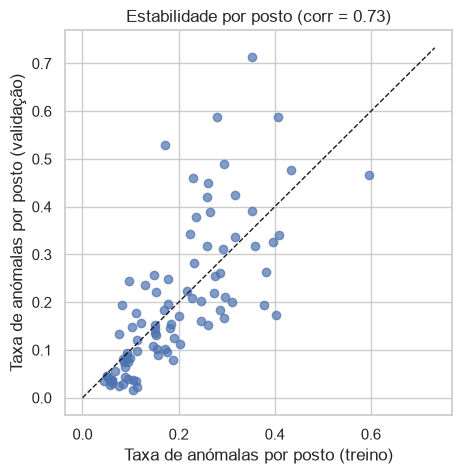

In [24]:
rate_tr = train.groupby("Charging Post ID")["is_Abnormal"].mean()
rate_va = val.groupby("Charging Post ID")["is_Abnormal"].mean()
d = pd.concat([rate_tr, rate_va], axis=1, keys=["treino", "validacao"])

plt.figure(figsize=(5, 5))
plt.scatter(d["treino"], d["validacao"], alpha=.7)
lim = [0, d.max().max() + .02]
plt.plot(lim, lim, "k--", lw=1)
plt.xlabel("Taxa de anómalas por posto (treino)")
plt.ylabel("Taxa de anómalas por posto (validação)")
plt.title(f"Estabilidade por posto (corr = {d['treino'].corr(d['validacao']):.2f})")
plt.show()

In [25]:
dur_min = (df["End Time"] - df["Start Time"]).dt.total_seconds() / 60
grupo = np.select(
    [df["end_cause"].eq("Charging ends normally"), df["end_cause"].eq("User stops charging")],
    ["Término normal", "Paragem do utilizador"], default="Falhas")

aud = pd.DataFrame({"grupo": grupo, "kwh": df["Transaction power/kwh"], "dur": dur_min})
res = aud.groupby("grupo").agg(
    n=("kwh", "size"),
    kwh_mediana=("kwh", "median"),
    dur_mediana_min=("dur", "median"),
    pct_kwh_zero=("kwh", lambda s: (s <= 0).mean()),
    pct_dur_menor_5min=("dur", lambda s: (s < 5).mean()),
)
display(res.round(3))

,n,kwh_mediana,dur_mediana_min,pct_kwh_zero,pct_dur_menor_5min
grupo,,,,,
Falhas,81934,0.000,2.217,0.556,0.635
Paragem do utilizador,155942,14.315,30.900,0.050,0.118
Término normal,203201,19.690,46.667,0.007,0.016


In [26]:
nan_cols = ["post_hours_since_previous_completed_session", "post_hours_since_previous_completed_abnormal",
            "user_days_since_previous_completed_session", "user_days_since_previous_completed_abnormal"]
print((df[nan_cols].isna().mean() * 100).round(2))

dur = (df["End Time"] - df["Start Time"]).dt.total_seconds() / 60
zero = df["Transaction power/kwh"] <= 0
print("\nkWh<=0:", zero.sum(), f"({zero.mean():.1%})")
print("Normais entre as kWh<=0:", (df.loc[zero, "is_Abnormal"] == 0).sum(), f"({(df.loc[zero, 'is_Abnormal'] == 0).mean():.1%})")
print("Anómalas com kWh<=0:", df.loc[zero, "is_Abnormal"].sum(),
      f"({df.loc[zero, 'is_Abnormal'].sum() / df['is_Abnormal'].sum():.1%} das anómalas)")
pay = df["Payment time"] < df["End Time"]
print("Pagamento antes do fim:", pay.sum(), f"({pay.mean():.1%})")
print("Duração < 1 min:", (dur < 1).sum(), f"({(dur < 1).mean():.1%}) | >= 1439 min:", (dur >= 1439).sum())
print("Duração > 600 min:", (dur > 600).sum(), f"({(dur > 600).mean():.2%}) | máxima:", dur.max().round(2), "min")
print("Temp. mínima por mês de inverno:")
print(df[df["ym"].astype(str).isin(["2019-12", "2020-01", "2020-02", "2020-12", "2021-01", "2021-02", "2021-12"])]
      .groupby("ym")["Temperature(℃)"].min())

post_hours_since_previous_completed_session      0.02
post_hours_since_previous_completed_abnormal     0.08
user_days_since_previous_completed_session      12.84
user_days_since_previous_completed_abnormal     30.90
dtype: float64

kWh<=0: 54621 (12.4%)
Normais entre as kWh<=0: 9058 (16.6%)
Anómalas com kWh<=0: 45563 (55.6% das anómalas)
Pagamento antes do fim: 87202 (19.8%)
Duração < 1 min: 19024 (4.3%) | >= 1439 min: 1
Duração > 600 min: 3217 (0.73%) | máxima: 1439.13 min
Temp. mínima por mês de inverno:
ym
2019-12    3.7
2020-01    3.9
2020-02    2.8
2020-12   -3.2
2021-01    0.5
2021-02    4.6
2021-12    0.0
Freq: M, Name: Temperature(℃), dtype: float64


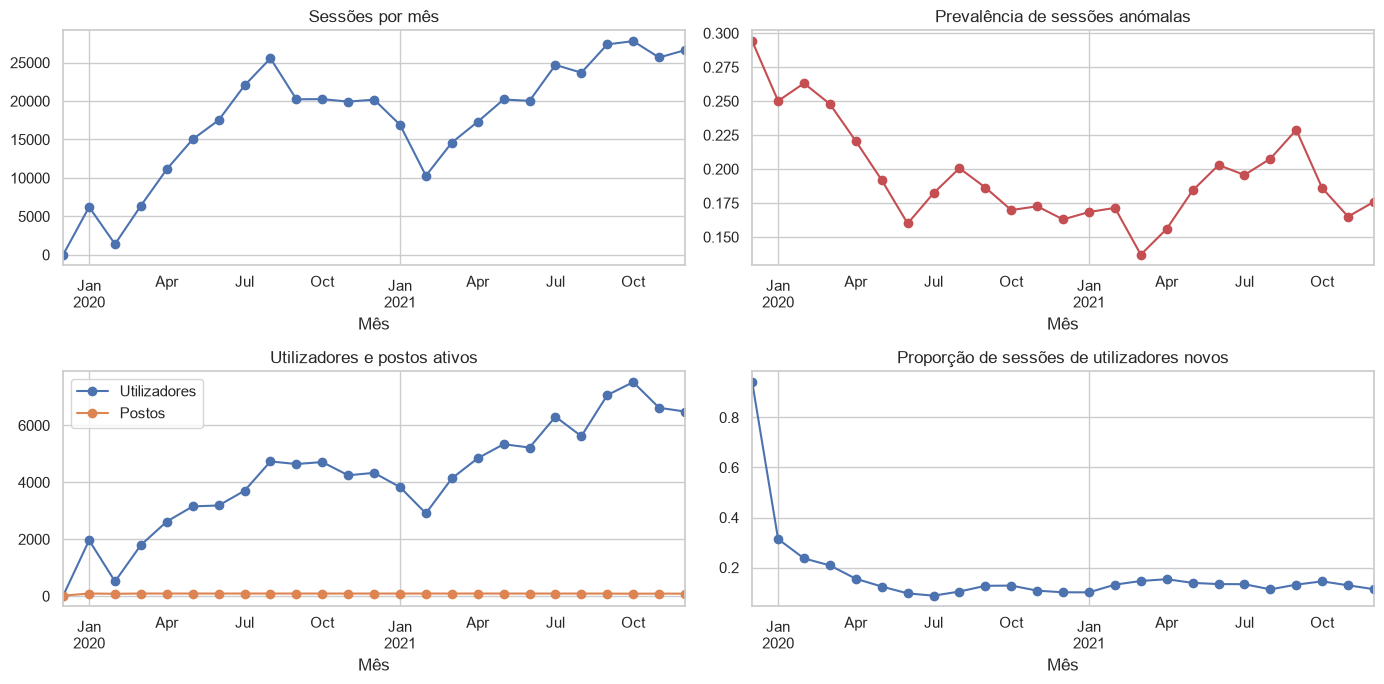

In [27]:
m2 = m.rename(columns={"users": "Utilizadores", "posts": "Postos"})
fig, ax = plt.subplots(2, 2, figsize=(14, 7))
m["n"].plot(ax=ax[0, 0], marker="o", title="Sessões por mês")
m["abn_rate"].plot(ax=ax[0, 1], marker="o", color="C3", title="Prevalência de sessões anómalas")
m2[["Utilizadores", "Postos"]].plot(ax=ax[1, 0], marker="o", title="Utilizadores e postos ativos")
m["new_user_share"].plot(ax=ax[1, 1], marker="o", title="Proporção de sessões de utilizadores novos")
for a in ax.ravel():
    a.set_xlabel("Mês")
plt.tight_layout()
plt.show()

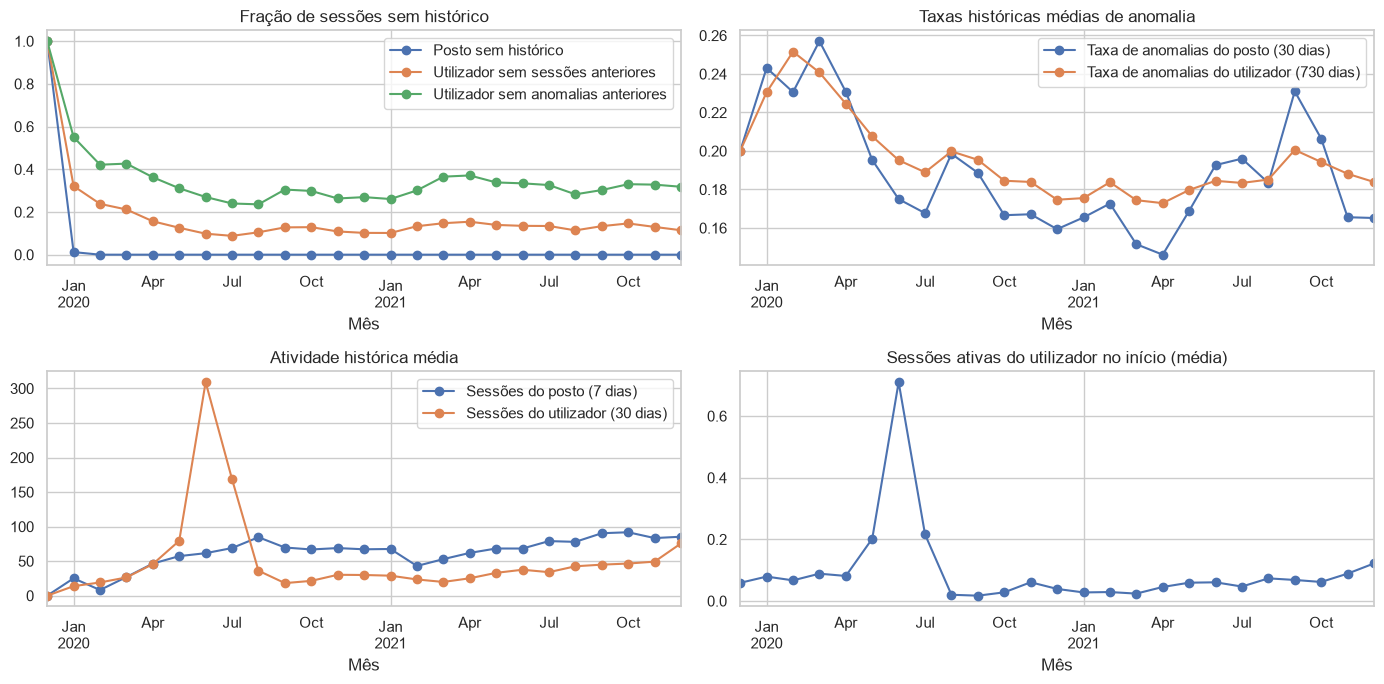

In [28]:
nomes = {"post_sem_hist": "Posto sem histórico",
         "user_sem_hist": "Utilizador sem sessões anteriores",
         "user_sem_hist_abn": "Utilizador sem anomalias anteriores",
         "post_abn_rate_30D": "Taxa de anomalias do posto (30 dias)",
         "user_abn_rate_730D": "Taxa de anomalias do utilizador (730 dias)",
         "post_sessions_7D": "Sessões do posto (7 dias)",
         "user_sessions_30D": "Sessões do utilizador (30 dias)",
         "active_at_start": "Sessões ativas do utilizador no início"}
c2 = cov.rename(columns=nomes)
fig, ax = plt.subplots(2, 2, figsize=(14, 7))
c2[[nomes[k] for k in ["post_sem_hist", "user_sem_hist", "user_sem_hist_abn"]]].plot(ax=ax[0, 0], marker="o", title="Fração de sessões sem histórico")
c2[[nomes[k] for k in ["post_abn_rate_30D", "user_abn_rate_730D"]]].plot(ax=ax[0, 1], marker="o", title="Taxas históricas médias de anomalia")
c2[[nomes[k] for k in ["post_sessions_7D", "user_sessions_30D"]]].plot(ax=ax[1, 0], marker="o", title="Atividade histórica média")
c2[nomes["active_at_start"]].plot(ax=ax[1, 1], marker="o", title="Sessões ativas do utilizador no início (média)")
for a in ax.ravel():
    a.set_xlabel("Mês")
plt.tight_layout()
plt.show()

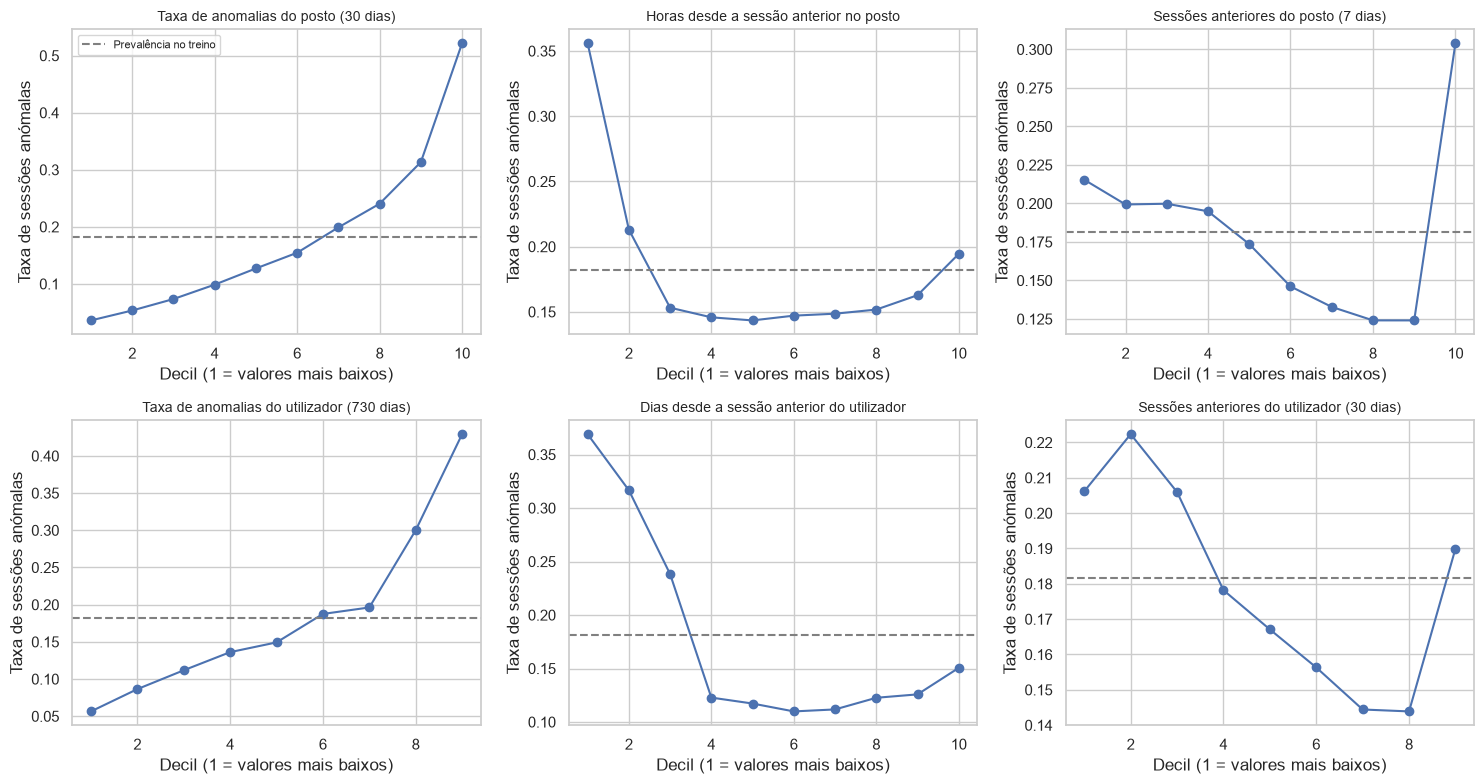

In [29]:
VARS = [
    ("post_previous_abnormal_rate_30D", "Taxa de anomalias do posto (30 dias)"),
    ("post_hours_since_previous_completed_session", "Horas desde a sessão anterior no posto"),
    ("post_previous_sessions_7D", "Sessões anteriores do posto (7 dias)"),
    ("user_previous_abnormal_rate_730D", "Taxa de anomalias do utilizador (730 dias)"),
    ("user_days_since_previous_completed_session", "Dias desde a sessão anterior do utilizador"),
    ("user_previous_sessions_30D", "Sessões anteriores do utilizador (30 dias)"),
]
base = train["is_Abnormal"].mean()
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for a, (c, titulo) in zip(ax.ravel(), VARS):
    q = pd.qcut(train[c], 10, duplicates="drop")
    r = train.groupby(q, observed=True)["is_Abnormal"].mean().to_numpy()
    a.plot(range(1, len(r) + 1), r, marker="o")
    a.axhline(base, color="gray", ls="--", label="Prevalência no treino")
    a.set_title(titulo, fontsize=10)
    a.set_xlabel("Decil (1 = valores mais baixos)")
    a.set_ylabel("Taxa de sessões anómalas")
ax[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

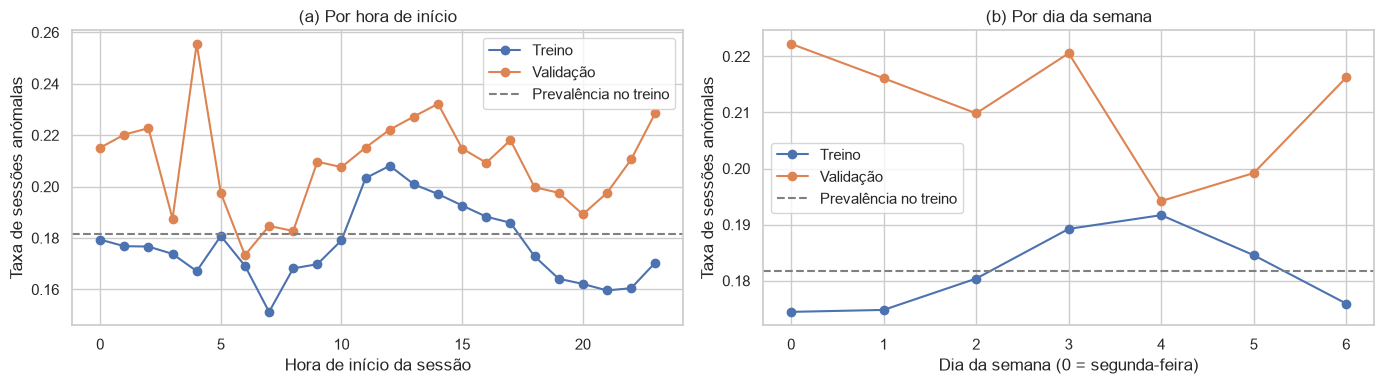

In [30]:
base = train["is_Abnormal"].mean()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, c, xl, tt in zip(ax, ["hour", "dow"],
                        ["Hora de início da sessão", "Dia da semana (0 = segunda-feira)"],
                        ["(a) Por hora de início", "(b) Por dia da semana"]):
    train.groupby(c)["is_Abnormal"].mean().plot(ax=a, marker="o", label="Treino")
    val.groupby(c)["is_Abnormal"].mean().plot(ax=a, marker="o", label="Validação")
    a.axhline(base, color="gray", ls="--", label="Prevalência no treino")
    a.set_xlabel(xl); a.set_ylabel("Taxa de sessões anómalas"); a.set_title(tt); a.legend()
plt.tight_layout()
plt.show()

In [31]:
for c, _ in VARS:
    q = pd.qcut(train[c], 10, duplicates="drop")
    print(c, train.groupby(q, observed=True)["is_Abnormal"].mean().round(3).to_numpy())

post_previous_abnormal_rate_30D [0.036 0.053 0.073 0.099 0.127 0.155 0.199 0.24  0.313 0.522]
post_hours_since_previous_completed_session [0.356 0.213 0.153 0.146 0.143 0.147 0.149 0.152 0.163 0.194]
post_previous_sessions_7D [0.215 0.199 0.2   0.195 0.174 0.146 0.133 0.124 0.124 0.304]
user_previous_abnormal_rate_730D [0.056 0.086 0.112 0.136 0.149 0.188 0.196 0.3   0.429]
user_days_since_previous_completed_session [0.369 0.317 0.238 0.123 0.117 0.11  0.112 0.123 0.126 0.151]
user_previous_sessions_30D [0.206 0.222 0.206 0.178 0.167 0.156 0.144 0.144 0.19 ]


In [32]:
x = train["user_active_sessions_at_start"] > 3
print(x.sum(), train.loc[x, "UserID"].isin([39, 23]).mean().round(3))

2640 0.976


In [33]:
met = ["Temperature(℃)", "Relative Humidity(%)", "Precipitation(mm)"]
g = train.groupby([train["Start Time"].dt.date, "District Name"])[met].nunique()
print(g.describe().loc[["mean", "max"]].round(2))

      Temperature(℃)  Relative Humidity(%)  Precipitation(mm)
mean             1.0                   1.0                1.0
max              1.0                   1.0                1.0


In [34]:
for c in ["hour", "dow"]:
    print(c)
    print(pd.DataFrame({"treino": train.groupby(c)["is_Abnormal"].mean(),
                        "validacao": val.groupby(c)["is_Abnormal"].mean()}).round(3).T)

hour
hour          0      1      2      3      4      5      6      7      8     9      10     11     12     13     14     15     16     17     18     19     20     21     22     23
treino     0.179  0.177  0.177  0.174  0.167  0.181  0.169  0.151  0.168  0.17  0.179  0.203  0.208  0.201  0.197  0.193  0.188  0.186  0.173  0.164  0.162  0.160  0.160  0.170
validacao  0.215  0.220  0.223  0.188  0.256  0.198  0.173  0.185  0.183  0.21  0.208  0.215  0.222  0.227  0.232  0.215  0.209  0.218  0.200  0.198  0.189  0.198  0.211  0.229
dow
dow            0      1     2      3      4      5      6
treino     0.174  0.175  0.18  0.189  0.192  0.185  0.176
validacao  0.222  0.216  0.21  0.221  0.194  0.199  0.216
